In [70]:
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
import torch.nn as nn
import matplotlib.pyplot as plt
import torch.optim as optim 
from torch.utils.data import Dataset , DataLoader 

In [71]:
torch.manual_seed(42)
#It fixes randomness in PyTorch so you get the same results every time you run your code.

In [72]:
df = pd.read_csv("fmnist_small.csv")
df

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,1,0,0,0,0,0,0,0,0,0,...,69,12,0,0,0,0,0,0,0,0
5996,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5997,8,0,0,0,0,0,0,0,0,0,...,39,47,2,0,0,29,0,0,0,0
5998,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


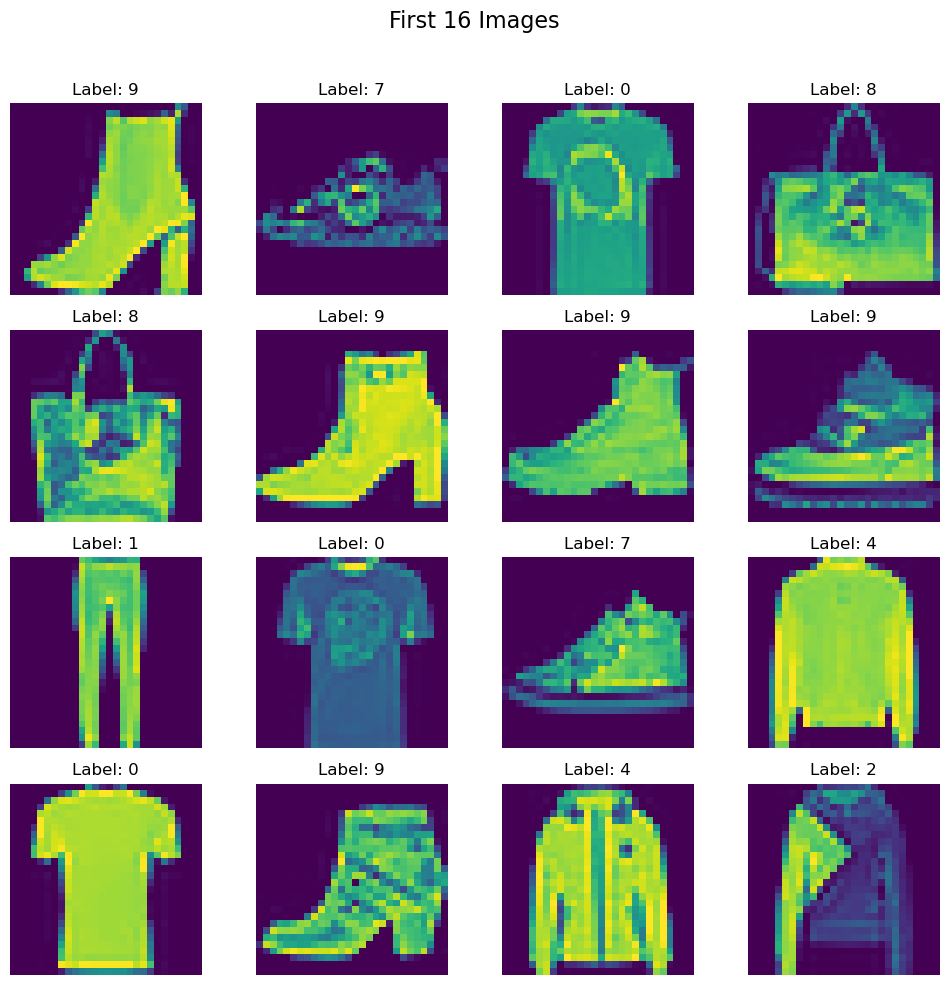

In [73]:
# Create a 4x4 grid of images
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("First 16 Images", fontsize=16)

# Plot the first 16 images from the dataset
for i, ax in enumerate(axes.flat):
    img = df.iloc[i, 1:].values.reshape(28, 28)  # Reshape to 28x28
    ax.imshow(img)  # Display in grayscale
    ax.axis('off')  # Remove axis for a cleaner look
    ax.set_title(f"Label: {df.iloc[i, 0]}")  # Show the label

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to fit the title
plt.show()

In [74]:
X=df.iloc[:,1:].values
y=df.iloc[:,0].values

In [75]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [76]:
#scaling the features
X_train = X_train/255.0
X_test = X_test/255.0

In [77]:
class customdataset(Dataset) :
    def __init__(self,features,labels) :
        self.features = torch.tensor(features,dtype = torch.float32)
        self.labels = torch.tensor(labels , dtype = torch.long)

    def __len__(self) :
        return len(self.features)

    def __getitem__(self,index) :
        return self.features[index] , self.labels[index] 
        

In [78]:
#create train dataset object
train_dataset = customdataset(X_train,y_train)

In [79]:
#create test dataset object
test_dataset = customdataset(X_test,y_test)

In [80]:
#create train and test data loader
train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=32,shuffle=False)
#shuffle off beacuse we don't want to shuffle data during prediction , it lowers the accuracy

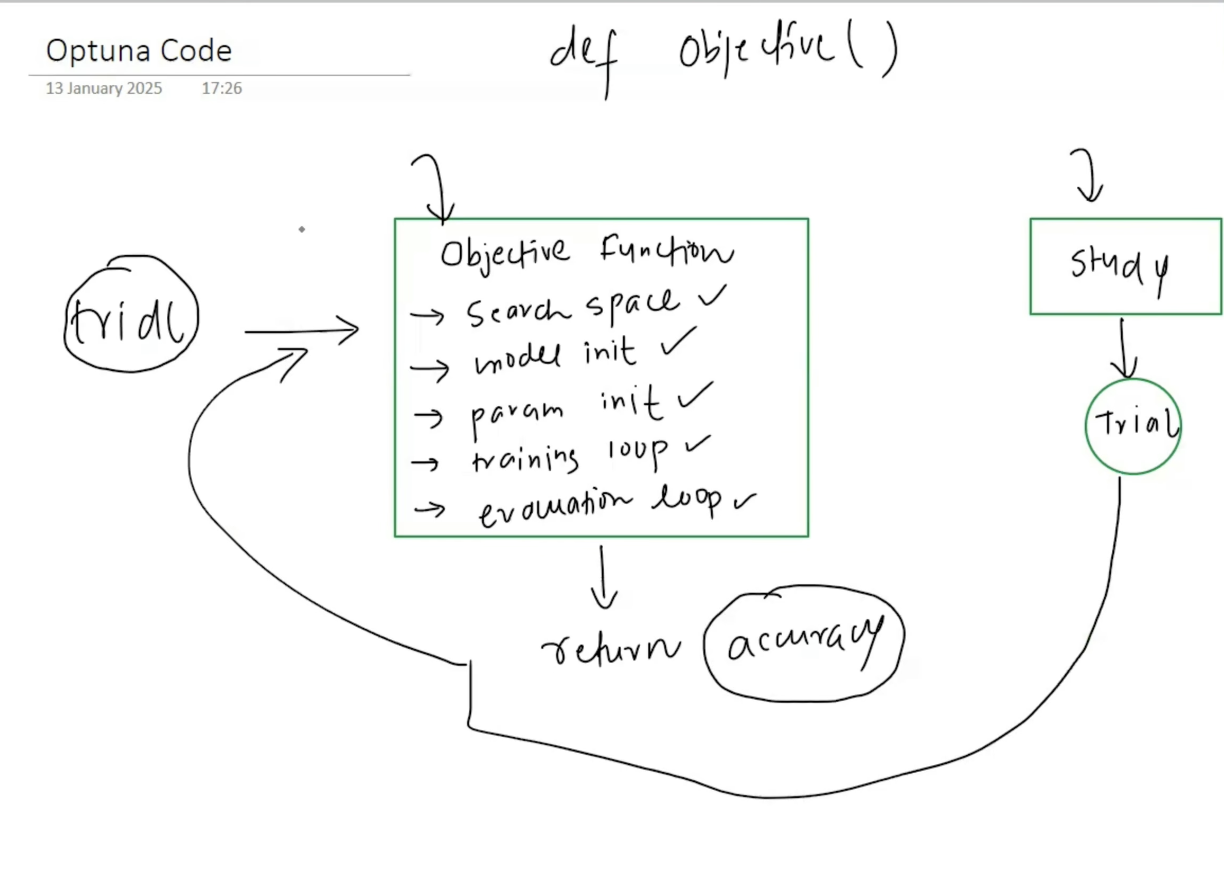 PICTURE OF OPTUNA ARCHITECTURE FOR HYPERPARAMETER TUNING MODEL

In [81]:
#DEFINING A MODEL
class myNN(nn.Module) :
    
  def __init__(self,num_features) :
      super().__init__() 
      self.model = nn.Sequential(
          nn.Linear(num_features,128) ,
          nn.ReLU(),
          nn.BatchNorm1d(128),
          nn.Dropout(p=0.3),
          nn.Linear(128,64),
          nn.BatchNorm1d(64),
          nn.ReLU(),
          nn.Dropout(p=0.3),
          nn.Linear(64,10) )
      #no need to add softmax explicitly as in cross entropy loss its default given there
   
  def forward(self,x) :
      
      return self.model(x)

In [82]:
epochs = 100
learning_rate = 0.001

In [83]:
loss_function = nn.CrossEntropyLoss()

In [84]:
len(train_loader)

150

In [85]:
# TRAINING PIPELINE

#CREATING MODEL
model = myNN(X_train.shape[1])

#define optimizer
optimizer = torch.optim.Adam(model.parameters(),lr=learning_rate,weight_decay=1e-4) #weight decay is regularization toreduce overfitting

#DEFINE LOOP
for epoch in range(epochs) :

    total_epoch_loss = 0 
    
    for batch_features  , batch_labels in train_loader  :
        
        #forward
        y_pred = model(batch_features)
        
        #loss
        loss = loss_function(y_pred,batch_labels)
    
    
       # Reset gradients
        optimizer.zero_grad()



        #backward
       
        loss.backward()

      #PARAMETERS UPDATING
        optimizer.step()

        total_epoch_loss = total_epoch_loss + loss.item()

    avg_loss=total_epoch_loss/len(train_loader)

    print(f'Epoch:{epoch+1} , Loss:{avg_loss}')



Epoch:1 , Loss:1.1579946231842042
Epoch:2 , Loss:0.734595176577568


Epoch:3 , Loss:0.6395242285728454
Epoch:4 , Loss:0.60221668501695


Epoch:5 , Loss:0.5827539411187171
Epoch:6 , Loss:0.5364699308077494


Epoch:7 , Loss:0.5460347852110863
Epoch:8 , Loss:0.5050045759479205


Epoch:9 , Loss:0.4862605234980583
Epoch:10 , Loss:0.4963282345732053


...

Epoch:91 , Loss:0.2782202828923861
Epoch:92 , Loss:0.2685511068503062


Epoch:93 , Loss:0.28666589011748633
Epoch:94 , Loss:0.2726278706391652


Epoch:95 , Loss:0.2814819611112277
Epoch:96 , Loss:0.27552217823763686


Epoch:97 , Loss:0.26644949927926065
Epoch:98 , Loss:0.2624164930482705


Epoch:99 , Loss:0.281505928337574
Epoch:100 , Loss:0.2879073642442624


In [86]:
#set model to eval mode
model.eval()

myNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [87]:
#finding output by finding labels
total = 0
correct = 0

with torch.no_grad():

    for batch_features, batch_labels in test_loader:

        outputs = model(batch_features)

        _, predicted = torch.max(outputs, 1)

        total = total + batch_labels.shape[0]

        correct = correct + (predicted == batch_labels).sum().item()

print(correct/total)


0.8116666666666666


In [88]:
#for test accuracy check
#finding output by finding labels
total = 0
correct = 0

with torch.no_grad():

    for batch_features, batch_labels in train_loader:

        outputs = model(batch_features)

        _, predicted = torch.max(outputs, 1)

        total = total + batch_labels.shape[0]

        correct = correct + (predicted == batch_labels).sum().item()

print(correct/total)

#model is overfitting 


0.9422916666666666
